In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm
import plotly.express as px
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# 페어쌍으로 묶인 아이템 시각화 비교 함수
def visualize_(df, pairs, ref_item, target_col=None):
    if target_col is None:
        target_col = np.append(["ym",ref_item],pairs[pairs["leading_item_id"] == ref_item]["following_item_id"].values)
    uss_df = df[target_col].copy()
    uss_long = uss_df.melt(id_vars="ym", var_name="item", value_name="value")
    bench = (
        uss_long.loc[uss_long["item"] == ref_item, ["ym", "value"]]
                .rename(columns={"value": "bench_value"})
    )
    dfc = uss_long.merge(bench, on="ym", how="left")
    plot_df = pd.concat(
        [
            dfc.assign(series="self",  val=dfc["value"]),
            dfc.assign(series=f"benchmark: {ref_item}", val=dfc["bench_value"])
        ],
        ignore_index=True
    )
    fig = px.line(
        plot_df,
        x="ym",
        y="val",
        color="series",
        facet_col="item",
        facet_col_wrap=6,
        facet_row_spacing=0.02,
        color_discrete_map={
            "self": "#2962FF",                 # 각 아이템(자기 자신)
            f"benchmark: {ref_item}": "#9E9E9E"  # 기준 라인(회색)
        }
    )

    fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]),)
    fig.update_traces(opacity=0.95)
    # fig.update_layout(width=1800, height=1400, showlegend=True)
    fig.update_layout(showlegend=True,)

    fig.show()
    
# 단순 페어쌍 갯수 변화 함수
def count_p(pairs1,pairs2):
    count = {}
    plus = 0
    neg = 0
    pairs = np.union1d(pairs1["leading_item_id"].unique(), pairs2["leading_item_id"].unique())
    for i in pairs:
        target_col = np.append(["ym",i],pairs1[pairs1["leading_item_id"] == i]["following_item_id"].values)
        target_col_sub = np.append(["ym",i],pairs2[pairs2["leading_item_id"] == i]["following_item_id"].values)
        temp_inter = np.intersect1d(target_col,target_col_sub,)
        temp_tar = np.setdiff1d(target_col,target_col_sub,)
        temp_tar = np.append(["ym",i],temp_tar)
        temp_tar_sub = np.setdiff1d(target_col_sub,target_col,)
        temp_tar_sub = np.append(["ym",i],temp_tar_sub)
        count[i] = [len(target_col)-2,len(target_col_sub)-2, len(temp_inter)-2, len(temp_tar)-2,len(temp_tar_sub)-2]
        plus += len(temp_tar)-2
        neg += len(temp_tar_sub)-2
    return count, plus, neg, plus - neg

# --- 2. 메타 정보 및 헬퍼 함수 ---

HS_CLASSIFICATION = {
    (1, 5): "01.동물성 생산품", (6, 14): "02.식물성 생산품", (15, 15): "03.지방과 기름",
    (16, 24): "04.조제식료품", (25, 27): "05.광물성 생산품", (28, 38): "06.화학공업생산품",
    (39, 40): "07.플라스틱과 고무", (41, 43): "08.원피·가죽·모피", (44, 46): "09.목재와 그 제품",
    (47, 49): "10.펄프·종이·인쇄서적", (50, 63): "11.방직용섬유와 그 제품", (64, 67): "12.신발·모자·우산·가발",
    (68, 70): "13.석·도자·유리제품", (71, 71): "14.진주·귀석·귀금속", (72, 83): "15.비(卑)금속과 그 제품",
    (84, 85): "16.기계류·전기기기", (86, 89): "17.수송기기", (90, 92): "18.광학·측정·의료기기",
    (93, 93): "19.무기", (94, 96): "20.잡품", (97, 97): "21.예술품·골동품",
}

def get_hs_cat(c):
    try:
        val = int(str(c)[:2]) if len(str(c))==4 else int(str(c)[:1])
        for r, name in HS_CLASSIFICATION.items():
            if r[0] <= val <= r[1]: return name
    except: pass
    return "99.기타"


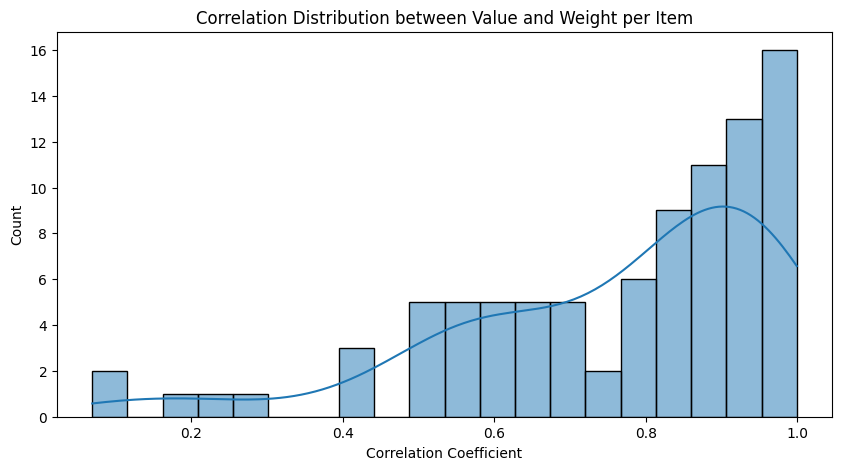

평균 상관계수: 0.760
상관계수 0.8 이상인 아이템 비율: 50.0%


In [7]:
# 데이터 로드
train = pd.read_csv('train.csv')
train['ym'] = pd.to_datetime(train['year'].astype(str) + '-' + train['month'].astype(str).str.zfill(2))

# 1. Value Pivot
pivot_v = train.pivot_table(index='item_id', columns='ym', values='value', aggfunc='sum').fillna(0)
# 2. Weight Pivot
pivot_w = train.pivot_table(index='item_id', columns='ym', values='weight', aggfunc='sum').fillna(0)

# 정렬 보장
pivot_v = pivot_v.sort_index().sort_index(axis=1)
pivot_w = pivot_w.sort_index().sort_index(axis=1)

# 아이템별 상관관계 분석
correlations = []
items = pivot_v.index
for item in items:
    v_series = pivot_v.loc[item]
    w_series = pivot_w.loc[item]
    
    # 둘 다 데이터가 어느정도 있어야 의미 있음
    if np.count_nonzero(v_series) > 10 and np.count_nonzero(w_series) > 10:
        corr = v_series.corr(w_series)
        correlations.append(corr)
    else:
        correlations.append(np.nan)

# 결과 시각화
plt.figure(figsize=(10, 5))
sns.histplot(correlations, bins=20, kde=True)
plt.title('Correlation Distribution between Value and Weight per Item')
plt.xlabel('Correlation Coefficient')
plt.show()

print(f"평균 상관계수: {np.nanmean(correlations):.3f}")
print(f"상관계수 0.8 이상인 아이템 비율: {np.mean(np.array(correlations) > 0.8):.1%}")

In [8]:
df = pivot_v.T.reset_index()
scaler = MinMaxScaler()
df_minmax = pd.DataFrame(scaler.fit_transform(df.drop("ym",axis=1)),columns=df.drop("ym",axis=1).columns).set_index(df["ym"]).reset_index()

In [10]:
df = np.log1p(pivot_v).T.reset_index()
scaler_log = MinMaxScaler()
df_minmax_log = pd.DataFrame(scaler_log.fit_transform(df.drop("ym",axis=1)),columns=df.drop("ym",axis=1).columns).set_index(df["ym"]).reset_index()

In [11]:
hs4 = pd.read_csv('./hs4_c.csv')
hs4.columns = ["index", 'hs4', 'tag']

In [8]:
tag = []
for i in train.hs4:
    tag.append(get_hs_cat(i))
train["hs4_tag"] = tag

In [9]:
tag_dict = {}
for i in train.hs4_tag.unique():
    tag_dict[i] = train[train.hs4_tag == i].item_id.unique().tolist()
tag_name = np.array(list(tag_dict.keys()))
np.array(list(tag_dict.keys()))

array(['06.화학공업생산품', '04.조제식료품', '05.광물성 생산품', '07.플라스틱과 고무',
       '08.원피·가죽·모피', '09.목재와 그 제품', '10.펄프·종이·인쇄서적', '11.방직용섬유와 그 제품',
       '15.비(卑)금속과 그 제품', '16.기계류·전기기기', '17.수송기기', '20.잡품', '02.식물성 생산품',
       '18.광학·측정·의료기기', '14.진주·귀석·귀금속'], dtype='<U15')

<Axes: xlabel='item_id', ylabel='item_id'>

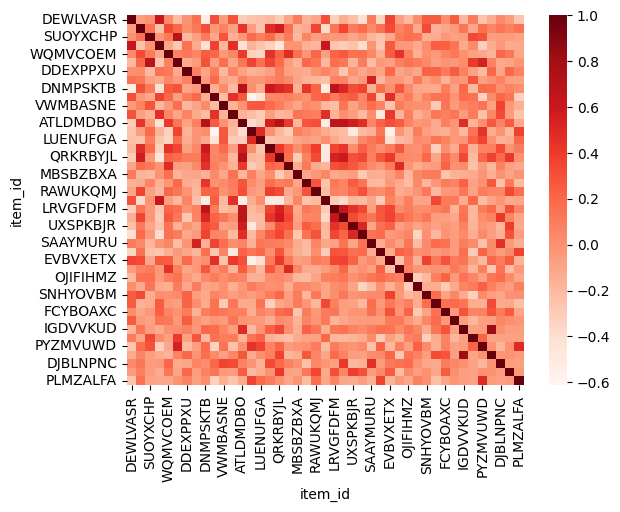

In [10]:
sns.heatmap(pivot_v.T[tag_dict['06.화학공업생산품']].corr(),cmap="Reds")

In [11]:
tag_name[0]

np.str_('06.화학공업생산품')

In [12]:
import plotly.express as px

# train의 앞 5개 열만 사용하여 이름 지정
# df = pivot.T.reset_index().iloc[:, 0:5].copy()
df = df_minmax[["ym"]+tag_dict[tag_name[0]]]
# df.columns = ["ym", "AANGBULD", "AHMDUILJ", "ANWUJOKX", "APQGTRMF"]  # R의 structure(names=...)와 동일

# pivot_longer() → melt()
lme_long = df.melt(id_vars="ym", var_name="Metal", value_name="value")

# ggplot(line) → plotly line
fig = px.line(
    lme_long,
    x="ym",
    y="value",
    color="Metal",
    # title="LME : Closing Price of Industrial Metals",
    labels={"date_id": "Date (date_id)", "value": ""}
)

# R의 figsize(16, 6) 비슷하게 크기 조정 (픽셀 단위)
fig.update_layout(width=1100, height=400, legend_title_text="Metal", margin=dict(l=40, r=20, t=60, b=40))

fig.show()

In [13]:
uss_df = df_minmax.copy()

# pivot_longer → melt
uss_long = uss_df.melt(id_vars="ym", var_name="item", value_name="value")

# ggplot(line) + facet_wrap(~ Stock, ncol=6) → plotly line + facet_col_wrap
fig = px.line(
    uss_long,
    x="ym",
    y="value",
    color="item",
    facet_col="item",
    facet_col_wrap=6,
    facet_row_spacing=0.02,   # ★ 세로 간격 축소
    color_discrete_sequence=["#2962FF"],
)

# 패싯 라벨 정리 & 범례 제거 & 레이아웃 크기 조정
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.update_layout(width=1800, height=2100, showlegend=False)

# 주의: y축을 0~150으로 제한해 대부분의 티커 가독성을 높였습니다. 고가 티커는 전체 범위가 보이지 않을 수 있습니다
fig.show()

In [14]:
# 0) 공통 전제: 두 DF 모두 첫 컬럼이 'ym', 나머지가 item 컬럼들
#    (예: df_minmax.columns = ['ym', 'A', 'B', ...])
#    x축(ym) 월 구성이 같다고 가정

# 1) 길게 만들기 + 출처(series) 라벨 부여
long_a = (
    df_minmax
      .melt(id_vars="ym", var_name="item", value_name="value")
      .assign(series="minmax")
)
long_b = (
    df_minmax_log
      .melt(id_vars="ym", var_name="item", value_name="value")
      .assign(series="minmax_log")
)

# 2) (선택) 공통 item만 사용하고 싶다면 inner merge 대신 교집합 필터
common_items = sorted(set(long_a["item"]).intersection(set(long_b["item"])))
long_a = long_a[long_a["item"].isin(common_items)]
long_b = long_b[long_b["item"].isin(common_items)]

# 3) 합치기
plot_df = pd.concat([long_a, long_b], ignore_index=True)

# 4) 라인 플롯: 패싯은 item, 색상/스타일은 series(두 개 라인)
fig = px.line(
    plot_df,
    x="ym",
    y="value",
    color="series",           # 각 패싯에 'minmax' vs 'minmax_vw'
    line_dash="series",       # 두 라인의 dash를 달리해서 더 잘 구분
    facet_col="item",
    facet_col_wrap=6,
    facet_row_spacing=0.02,
    # 원하시는 색이 있다면 아래 맵을 쓰세요 (없으면 Plotly 기본 팔레트 사용)
    color_discrete_map={
        "minmax": "#2962FF",
        "minmax_log": "#3B3A3A",
    },
    category_orders={"series": ["minmax", "minmax_log"]},
)

# 5) 패싯 제목 간소화(=뒤 텍스트만 남기기) + 레이아웃
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.update_layout(width=1800, height=2100, legend_title_text="Series", showlegend=True)

# 6) (선택) y축 범위 고정
#    두 시계열이 동일 스케일이라면 아래처럼 고정 가능
# for ax in fig.layout:
#     if ax.startswith("yaxis"):
#         fig.layout[ax].update(range=[0, 150])

# 7) (선택) hover 깔끔하게
fig.update_traces(hovertemplate="ym=%{x}<br>%{legendgroup}: %{y:.2f}")

fig.show()

In [12]:
# --- 1. 전처리 함수 정의 ---

def preprocess_log_diff(df: pd.DataFrame) -> pd.DataFrame:
    """로그 차분 (변화율): 추세 제거, 단기 변동성 집중"""
    # log(t) - log(t-1), 첫 컬럼은 NaN이므로 0으로 채움
    return np.log1p(df.astype(float)).diff(axis=1).fillna(0)

def preprocess_diff(df: pd.DataFrame) -> pd.DataFrame:
    """차분 (변화율): 추세 제거, 단기 변동성 집중"""
    # log(t) - log(t-1), 첫 컬럼은 NaN이므로 0으로 채움
    return df.diff(axis=1).fillna(0)

def preprocess_log(df: pd.DataFrame) -> pd.DataFrame:
    """로그"""
    # log(t) - log(t-1), 첫 컬럼은 NaN이므로 0으로 채움
    return np.log1p(df.astype(float)).fillna(0)

def preprocess_minmax(df: pd.DataFrame) -> pd.DataFrame:
    """Min-Max 정규화: (x - min) / (max - min), 0~1 사이로 변환"""
    values = df.values.astype(float)
    row_min = values.min(axis=1, keepdims=True)
    row_max = values.max(axis=1, keepdims=True)
    denom = row_max - row_min
    
    # 모든 값이 같아서 분모가 0인 경우 1로 대체하여 나눗셈 오류 방지
    denom[denom == 0] = 1.0
    
    norm_values = (values - row_min) / denom
    return pd.DataFrame(norm_values, index=df.index, columns=df.columns)


# --- 3. [핵심] Value + Weight 혼합 및 전처리 선택 기능 추가 ---

def find_pairs_with_value_weight_mix(
    pivot_v: pd.DataFrame,          # Value Pivot
    pivot_w: pd.DataFrame,          # Weight Pivot
    item_meta: pd.DataFrame,        # train.csv 등 메타 정보
    preprocess_method: str = 'log_diff', # 'log_diff' or 'minmax', 'log' 선택
    alpha: float = 0.7,             # Value 비중
    score_threshold: float = 0.45,  # 최종 점수 커트라인
    w_same_hs4: float = 1.15,       # HS4 가중치
    w_same_cat: float = 1.10,       # 대분류 가중치
    max_lag: int = 6,
    min_nonzero: int = 12
):
    # A. 데이터 정렬
    pivot_v = pivot_v.sort_index().sort_index(axis=1)
    pivot_w = pivot_w.sort_index().sort_index(axis=1)
    
    # B. 전처리 방식 선택 및 적용
    print(f"[{preprocess_method}] 방식으로 전처리를 수행합니다...")
    if preprocess_method == 'minmax':
        diff_v = preprocess_minmax(pivot_v)
        diff_w = preprocess_minmax(pivot_w)
    elif preprocess_method == 'log_diff':
        diff_v = preprocess_log_diff(pivot_v)
        diff_w = preprocess_log_diff(pivot_w)
    elif preprocess_method == 'log':
        diff_v = preprocess_log(pivot_v)
        diff_w = preprocess_log(pivot_w)
    elif preprocess_method == 'diff':
        diff_v = preprocess_diff(pivot_v)
        diff_w = preprocess_diff(pivot_w)
    else:
        raise ValueError("preprocess_method must be 'log_diff' or 'minmax' and 'log'")
    
    # C. 신호 혼합 (Ensemble Signal)
    combined_signal = pd.DataFrame(index=diff_v.index, columns=diff_v.columns)
    
    # Weight 데이터 품질 체크를 위해 원본 데이터 사용 (0 개수 확인용)
    raw_w_matrix = pivot_w.values
    items = diff_v.index.tolist()
    item_to_idx = {itm: i for i, itm in enumerate(items)}

    for item in items:
        idx = item_to_idx[item]
        v_row = diff_v.iloc[idx] # iloc이 속도가 조금 더 빠름
        w_row = diff_w.iloc[idx]
        
        # Weight 데이터가 부실하면(0이 너무 많으면) Value만 사용
        if np.count_nonzero(raw_w_matrix[idx]) < min_nonzero: 
            combined_signal.iloc[idx] = v_row
        else:
            # Value와 Weight 혼합
            combined_signal.iloc[idx] = (v_row * alpha) + (w_row * (1 - alpha))
            
    # D. 메타 정보 Dictionary 생성
    meta = item_meta[['item_id', 'hs4']].drop_duplicates().set_index('item_id')
    meta['category'] = meta['hs4'].apply(get_hs_cat)
    hs_dict = meta['hs4'].to_dict()
    cat_dict = meta['category'].to_dict()
    
    # E. 탐색 루프 준비
    matrix = combined_signal.values.astype(float) # 혼합된 신호
    raw_v_matrix = pivot_v.values                 # 0 체크용
    
    results = []
    
    desc_text = f"Searching ({preprocess_method}, alpha={alpha})"
    for leader in tqdm(items, desc=desc_text):
        l_idx = item_to_idx[leader]
        # 데이터가 너무 없으면 스킵
        if np.count_nonzero(raw_v_matrix[l_idx]) < min_nonzero: continue
        
        x = matrix[l_idx]
        l_hs = hs_dict.get(leader, -1)
        l_cat = cat_dict.get(leader, "Unknown")
        
        for follower in items:
            if leader == follower: continue
            f_idx = item_to_idx[follower]
            if np.count_nonzero(raw_v_matrix[f_idx]) < min_nonzero: continue
            
            y = matrix[f_idx]
            f_hs = hs_dict.get(follower, -2)
            f_cat = cat_dict.get(follower, "Unknown")
            
            # 가중치 산정
            weight = 1.0
            if l_hs == f_hs: weight = w_same_hs4
            elif l_cat == f_cat: weight = w_same_cat
            
            best_stats = None
            max_final_score = -1.0
            
            for lag in range(1, max_lag + 1):
                x_slice = x[:-lag]
                y_slice = y[lag:]
                
                # 길이가 너무 짧으면 스킵
                if len(x_slice) < min_nonzero: continue
                
                # 표준편차 0이면 상관계수 0
                if np.std(x_slice) < 1e-9 or np.std(y_slice) < 1e-9:
                    corr = 0.0
                else:
                    corr = np.corrcoef(x_slice, y_slice)[0, 1]
                
                # if abs(corr) < 0.1: continue
                
                # 점수 계산
                # minmax의 경우 값의 범위가 양수이므로 상관계수 해석은 동일함
                base_score = abs(corr)
                final_score = base_score * weight
                
                if final_score > max_final_score:
                    max_final_score = final_score
                    best_stats = {
                        "leading_item_id": leader,
                        "following_item_id": follower,
                        "best_lag": lag,
                        "max_corr": corr,
                        "final_score": final_score,
                        "l_hs":l_hs,
                        "l_cat":l_cat,
                        "f_hs":f_hs,
                        "f_cat":f_cat,
                    }
            
            if best_stats and max_final_score >= score_threshold:
                results.append(best_stats)
                
    # 결과 반환
    if not results:
        print("조건을 만족하는 쌍이 없습니다.")
        return pd.DataFrame()
        
    return pd.DataFrame(results)

In [13]:
pairs = find_pairs_with_value_weight_mix(
    pivot_v = pivot_v,
    pivot_w = pivot_w,
    item_meta = train,
    alpha=1.0,
    max_lag=12,
    min_nonzero=12,
    score_threshold=0.0,
    w_same_hs4=1.2,
    preprocess_method='minmax'
)


print("탐색된 공행성쌍 수:", len(pairs))
pairs

[minmax] 방식으로 전처리를 수행합니다...


Searching (minmax, alpha=1.0): 100%|██████████| 100/100 [00:23<00:00,  4.31it/s]

탐색된 공행성쌍 수: 8190


,leading_item_id,following_item_id,best_lag,max_corr,final_score,l_hs,l_cat,f_hs,f_cat
0,AANGBULD,AHMDUILJ,19,0.514831,0.514831,4810,10.펄프·종이·인쇄서적,2102,04.조제식료품
1,AANGBULD,APQGTRMF,8,-0.480115,0.480115,4810,10.펄프·종이·인쇄서적,8105,15.비(卑)금속과 그 제품
2,AANGBULD,ATLDMDBO,23,0.283444,0.283444,4810,10.펄프·종이·인쇄서적,2814,06.화학공업생산품
3,AANGBULD,AXULOHBQ,23,-0.588100,0.588100,4810,10.펄프·종이·인쇄서적,5515,11.방직용섬유와 그 제품
4,AANGBULD,BEZYMBBT,10,-0.483240,0.483240,4810,10.펄프·종이·인쇄서적,3207,06.화학공업생산품
...,...,...,...,...,...,...,...,...,...
8185,ZXERAXWP,XUOIQPFL,1,-0.353922,0.353922,4802,10.펄프·종이·인쇄서적,5205,11.방직용섬유와 그 제품
8186,ZXERAXWP,YSYHGLQK,1,0.374210,0.374210,4802,10.펄프·종이·인쇄서적,2807,06.화학공업생산품
8187,ZXERAXWP,ZCELVYQU,18,-0.347675,0.347675,4802,10.펄프·종이·인쇄서적,8461,16.기계류·전기기기
8188,ZXERAXWP,ZGJXVMNI,15,0.300692,0.300692,4802,10.펄프·종이·인쇄서적,3006,06.화학공업생산품


In [15]:
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings

warnings.filterwarnings("ignore")

# --- 1. 계절성 제거 함수 ---
def remove_seasonality(series, period=12):
    """
    시계열에서 계절성을 제거하고 Trend+Residual만 반환합니다.
    데이터 길이가 짧으면(2주기 미만) 원본을 그대로 반환합니다.
    """
    if len(series) < period * 2:
        return series
    
    try:
        # additive 모델 사용 (값 = Trend + Seasonality + Residual)
        result = seasonal_decompose(series, model='additive', period=period, extrapolate_trend='freq')
        # 계절성만 뺀 값 반환 (Trend + Residual)
        deseasoned = series - result.seasonal
        return deseasoned
    except:
        return series

# --- 2. 그레인저 인과관계 검정 함수 ---
def check_granger_causality(leader_series, follower_series, max_lag=3):
    """
    Leader가 Follower의 원인이 되는지 검정 (p-value 반환)
    p-value < 0.05 이면 인과관계 있음 (유의미)
    """
    # 데이터 프레임 생성 (follower가 1열, leader가 2열이어야 함)
    df = pd.DataFrame({'y': follower_series, 'x': leader_series})
    
    try:
        # max_lag까지 테스트 수행
        # verbose=False로 로그 출력 억제
        gc_res = grangercausalitytests(df, maxlag=max_lag, verbose=False)
        # gc_res = grangercausalitytests(df, maxlag=max_lag)
        
        min_p_value = 1.0
        # 각 lag별 테스트 중 가장 유의미한(작은) p-value 찾기
        for lag in range(1, max_lag + 1):
            # ssr_chi2test 등의 p-value 추출 (인덱스 1이 p-value)
            p_val = gc_res[lag][0]['ssr_chi2test'][1]
            if p_val < min_p_value:
                min_p_value = p_val
                
        return min_p_value
    except:
        return 1.0 # 에러 시 유의하지 않음으로 처리

# --- 3. 통합 검증 함수 (기존 파이프라인에 끼워넣기) ---
def validate_pairs_advanced(
    pairs_df: pd.DataFrame, 
    pivot_value: pd.DataFrame,
    p_value_threshold: float = 0.05, # 이보다 작아야 통과
    use_deseason: bool = True
):
    """
    찾아낸 Pair 후보들에 대해 2차 검증(계절성 제거 후 재확인 + 그레인저 테스트)을 수행
    """
    print(f"고급 검증 시작... (대상: {len(pairs_df)}쌍)")
    
    pivot_value = pivot_value.sort_index().sort_index(axis=1)
    validated_results = []
    
    # pivot 데이터를 딕셔너리나 numpy로 변환해두면 더 빠름
    data_matrix = pivot_value.values
    items = pivot_value.index.tolist()
    item_map = {item: i for i, item in enumerate(items)}
    
    for idx, row in tqdm(pairs_df.iterrows(), total=len(pairs_df)):
        leader = row['leading_item_id']
        follower = row['following_item_id']
        original_score = row.get('final_score', 0)
        original_corr = row.get('max_corr', 0)
        lag = int(row.get('best_lag', 1))
        
        # 데이터 가져오기
        l_idx = item_map.get(leader)
        f_idx = item_map.get(follower)
        
        if l_idx is None or f_idx is None: continue
        
        x = data_matrix[l_idx] # Leader
        y = data_matrix[f_idx] # Follower
        
        # A. 계절성 제거 후 상관계수 재확인 (옵션)
        # 계절성을 제거했는데도 상관관계가 높다면 "진짜" 관계
        deseason_corr = 0.0
        if use_deseason:
            x_ds = remove_seasonality(x)
            y_ds = remove_seasonality(y)
            
            # Lag 적용 후 상관계수
            if len(x_ds) > lag:
                # 안전한 상관계수 계산 함수 (이전 코드 활용 가정)
                if np.std(x_ds[:-lag]) > 1e-9 and np.std(y_ds[lag:]) > 1e-9:
                    deseason_corr = np.corrcoef(x_ds[:-lag], y_ds[lag:])[0, 1]
        
        # B. 그레인저 인과관계 테스트 (원본 데이터 사용)
        # 차분(diff)된 데이터를 넣는 것이 정석입니다. 
        # (이미 앞단에서 log_diff 처리가 되었다면 그 데이터를 넣으면 됩니다.)
        # 여기서는 편의상 원본을 넣거나, 필요시 np.diff(x) 등을 사용하세요.
        
        p_val = check_granger_causality(np.diff(x), np.diff(y), max_lag=min(lag+1, 6))
        # p_val = check_granger_causality(np.diff(np.log1p(x)), np.diff(np.log1p(y)), max_lag=min(lag+1, 6))
        # p_val = check_granger_causality(x, y, max_lag=min(lag+1, 6))
        
        # C. 최종 평가
        # 그레인저 테스트 통과 여부
        is_causal = (p_val < p_value_threshold)
        
        # 계절성 제거 후에도 상관성이 유지되는가? (예: 원본의 70% 이상 유지)
        is_robust_season = True
        if use_deseason:
            # 계절성 제거 후 상관계수가 너무 뚝 떨어지면(예: 0.8 -> 0.1) 가짜일 확률 높음
            if abs(deseason_corr) < abs(original_corr) * 0.5: 
                is_robust_season = False
        
        # 결과 저장
        res = row.to_dict()
        res['granger_p_value'] = round(p_val, 4)
        res['is_causal'] = is_causal
        res['deseason_corr'] = round(deseason_corr, 4)
        res['is_robust'] = is_robust_season
        
        # 점수 페널티/보너스 부여 (예시)
        # 인과관계가 증명되면 점수 10% 보너스, 아니면 10% 감점
        bonus = 1.15 if is_causal else 0.85
        if use_deseason and not is_robust_season:
            bonus *= 0.8 # 계절성 빨이었으면 점수 대폭 깎음
            
        res['validated_score'] = original_score * bonus
        
        validated_results.append(res)
        
    result_df = pd.DataFrame(validated_results)
    return result_df

# --- 실행 예시 ---
final_pairs = validate_pairs_advanced(pairs, pivot_v,p_value_threshold = 0.05)
print("탐색된 공행성쌍 수:", len(final_pairs))
final_pairs.head()
# print(final_pairs[['leading_item_id', 'following_item_id', 'final_score', 'granger_p_value', 'validated_score']].head())

고급 검증 시작... (대상: 8190쌍)


100%|██████████| 8190/8190 [01:38<00:00, 83.43it/s]


탐색된 공행성쌍 수: 8190


,leading_item_id,following_item_id,best_lag,max_corr,final_score,l_hs,l_cat,f_hs,f_cat,granger_p_value,is_causal,deseason_corr,is_robust,validated_score
0,AANGBULD,AHMDUILJ,19,0.514831,0.514831,4810,10.펄프·종이·인쇄서적,2102,04.조제식료품,0.1077,False,0.3351,True,0.437606
1,AANGBULD,APQGTRMF,8,-0.480115,0.480115,4810,10.펄프·종이·인쇄서적,8105,15.비(卑)금속과 그 제품,0.0003,True,-0.5152,True,0.576137
2,AANGBULD,ATLDMDBO,23,0.283444,0.283444,4810,10.펄프·종이·인쇄서적,2814,06.화학공업생산품,0.5823,False,-0.1451,True,0.240927
3,AANGBULD,AXULOHBQ,23,-0.588100,0.588100,4810,10.펄프·종이·인쇄서적,5515,11.방직용섬유와 그 제품,0.6651,False,0.1459,False,0.399908
4,AANGBULD,BEZYMBBT,10,-0.483240,0.483240,4810,10.펄프·종이·인쇄서적,3207,06.화학공업생산품,0.1961,False,-0.3748,True,0.410754


In [51]:
final_pairs_2 = final_pairs[(np.abs(final_pairs["validated_score"]) > 0.41)]
final_pairs_2

,leading_item_id,following_item_id,best_lag,max_corr,final_score,l_hs,l_cat,f_hs,f_cat,granger_p_value,is_causal,deseason_corr,is_robust,validated_score
1,AANGBULD,APQGTRMF,8,-0.480115,0.480115,4810,10.펄프·종이·인쇄서적,8105,15.비(卑)금속과 그 제품,0.0003,True,-0.5152,True,0.576137
6,AANGBULD,BLANHGYY,15,0.867703,0.867703,4810,10.펄프·종이·인쇄서적,9022,18.광학·측정·의료기기,0.0850,False,0.5414,True,0.737548
13,AANGBULD,DEWLVASR,6,0.640221,0.640221,4810,10.펄프·종이·인쇄서적,3038,06.화학공업생산품,0.0004,True,0.7107,True,0.768265
17,AANGBULD,ELQGMQWE,14,0.558635,0.558635,4810,10.펄프·종이·인쇄서적,2002,04.조제식료품,0.0328,True,0.4328,True,0.670362
24,AANGBULD,FTSVTTSR,3,0.531400,0.531400,4810,10.펄프·종이·인쇄서적,2529,05.광물성 생산품,0.0000,True,0.5388,True,0.637680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8133,ZXERAXWP,JERHKLYW,14,0.430003,0.430003,4802,10.펄프·종이·인쇄서적,4601,09.목재와 그 제품,0.0035,True,0.3043,True,0.516004
8140,ZXERAXWP,LPHPPJUG,22,0.622059,0.622059,4802,10.펄프·종이·인쇄서적,3824,06.화학공업생산품,0.1330,False,0.5779,True,0.528751
8148,ZXERAXWP,NZKBIBNU,24,0.420230,0.420230,4802,10.펄프·종이·인쇄서적,5609,11.방직용섬유와 그 제품,0.0100,True,0.3560,True,0.504276
8170,ZXERAXWP,UIFPPCLR,1,-0.526205,0.526205,4802,10.펄프·종이·인쇄서적,8102,15.비(卑)금속과 그 제품,0.0028,True,-0.5557,True,0.631446


## 4. 회귀 모델 학습
- 시계열 데이터 안에서 '한 달 뒤 총 무역량(value)을 맞추는 문제'로 self-supervised 학습
- 탐색된 모든 공행성쌍 (A,B)에 대해 월 t마다 학습 샘플 생성
- input X:
1) B_t (현재 총 무역량(value))
2) B_{t-1} (직전 달 총 무역량(value))
3) A_{t-lag} (lag 반영된 총 무역량(value))
4) max_corr, best_lag (관계 특성)
- target y:
1) B_{t+1} (다음 달 총 무역량(value))
- 이러한 모든 샘플을 합쳐 LinearRegression 회귀 모델을 학습

In [454]:
def build_training_data(pivot, pairs):
    """
    공행성쌍 + 시계열을 이용해 (X, y) 학습 데이터를 만드는 함수
    input X:
      - b_t, b_t_1, a_t_lag, max_corr, best_lag
    target y:
      - b_t_plus_1
    """
    months = pivot.columns.to_list()
    n_months = len(months)

    rows = []

    for row in pairs.itertuples(index=False):
        leader = row.leading_item_id
        follower = row.following_item_id
        lag = int(row.best_lag)
        corr = float(row.max_corr)
        granger_p_value = float(row.granger_p_value)
        deseason_corr = float(row.deseason_corr)
        validated_score = float(row.validated_score)

        if leader not in pivot.index or follower not in pivot.index:
            continue

        a_series = pivot.loc[leader].values.astype(float)
        b_series = pivot.loc[follower].values.astype(float)

        # t+1이 존재하고, t-lag >= 0인 구간만 학습에 사용
        for t in range(max(lag, 1), n_months - 1):
            b_t = b_series[t]
            b_t_1 = b_series[t - 1]
            b_t_2 = b_series[t - 2]
            a_t_lag = a_series[t - lag]
            b_t_plus_1 = b_series[t + 1]
            month = (t % 12)+1
            month_sin = np.sin(2 * np.pi * month / 12)
            month_cos = np.cos(2 * np.pi * month / 12)
            rows.append({
                  "month": months[t], 
                  "leader":leader,
                  "follower":follower,
                  "leader_follower":(leader,follower),
                  "b_t": b_t,
                  "b_t_1": b_t_1,
                  "b_t_2": b_t_2,
                  "a_t_lag": a_t_lag,
                  "max_corr": corr,
                  "best_lag": float(lag),
                  "month_sin":month_sin,
                  "month_cos":month_cos,
                  "granger_p_value":granger_p_value,
                  "deseason_corr":deseason_corr,
                  "validated_score":validated_score,
                  "target": b_t_plus_1,
                  
              })

    df_train = pd.DataFrame(rows)
    return df_train

df_train_model = build_training_data(pivot_v, final_pairs_2)
df_train_model_w = build_training_data(pivot_w, final_pairs_2)
print('생성된 학습 데이터의 shape :', df_train_model.shape)
df_train_model.head()

생성된 학습 데이터의 shape : (81677, 16)


,month,leader,follower,leader_follower,b_t,b_t_1,b_t_2,a_t_lag,max_corr,best_lag,month_sin,month_cos,granger_p_value,deseason_corr,validated_score,target
0,2022-09-01,AANGBULD,APQGTRMF,"(AANGBULD, APQGTRMF)",537693.0,216019.0,759980.0,14276.0,-0.480115,8.0,-1.000000e+00,-1.836970e-16,0.0003,-0.5152,0.576137,205326.0
1,2022-10-01,AANGBULD,APQGTRMF,"(AANGBULD, APQGTRMF)",205326.0,537693.0,216019.0,52347.0,-0.480115,8.0,-8.660254e-01,5.000000e-01,0.0003,-0.5152,0.576137,169440.0
2,2022-11-01,AANGBULD,APQGTRMF,"(AANGBULD, APQGTRMF)",169440.0,205326.0,537693.0,53549.0,-0.480115,8.0,-5.000000e-01,8.660254e-01,0.0003,-0.5152,0.576137,698033.0
3,2022-12-01,AANGBULD,APQGTRMF,"(AANGBULD, APQGTRMF)",698033.0,169440.0,205326.0,0.0,-0.480115,8.0,-2.449294e-16,1.000000e+00,0.0003,-0.5152,0.576137,367604.0
4,2023-01-01,AANGBULD,APQGTRMF,"(AANGBULD, APQGTRMF)",367604.0,698033.0,169440.0,26997.0,-0.480115,8.0,5.000000e-01,8.660254e-01,0.0003,-0.5152,0.576137,216414.0


In [455]:
df_train_model[["b_t_w","b_t_1_w","b_t_2_w","a_t_lag_w",]] = df_train_model_w[["b_t","b_t_1","b_t_2","a_t_lag"]]

In [456]:
df_train_model["b_t_price"] = df_train_model["b_t"] / (df_train_model["b_t_w"] + 1e-9)
df_train_model[['b_t', 'b_t_1','b_t_2', 'a_t_lag', 'target','b_t_w', 'b_t_1_w', 'b_t_2_w', 'a_t_lag_w','b_t_price']] = np.log1p(df_train_model[['b_t', 'b_t_1','b_t_2', 'a_t_lag', 'target','b_t_w', 'b_t_1_w', 'b_t_2_w', 'a_t_lag_w','b_t_price']])

In [457]:
df_train_model.corr(numeric_only=True)

,b_t,b_t_1,b_t_2,a_t_lag,max_corr,best_lag,month_sin,month_cos,granger_p_value,deseason_corr,validated_score,target,b_t_w,b_t_1_w,b_t_2_w,a_t_lag_w,b_t_price
b_t,1.000000,0.761787,0.767994,0.043400,-0.157970,0.031195,-0.011373,0.005357,0.060603,-0.140423,-0.006677,0.764454,0.871744,0.721900,0.728301,0.025708,-0.151229
b_t_1,0.761787,1.000000,0.761716,0.037523,-0.155776,0.031047,-0.009003,0.008457,0.059787,-0.138193,-0.005941,0.770843,0.723445,0.871828,0.721492,0.021386,-0.219169
b_t_2,0.767994,0.761716,1.000000,0.035948,-0.154537,0.031316,-0.006164,0.009434,0.059316,-0.137117,-0.004959,0.749832,0.728534,0.724766,0.871612,0.020272,-0.227996
a_t_lag,0.043400,0.037523,0.035948,1.000000,-0.084246,0.044759,0.004985,0.002043,0.033269,-0.072191,-0.016028,0.034488,0.038182,0.033487,0.032430,0.879145,-0.003110
max_corr,-0.157970,-0.155776,-0.154537,-0.084246,1.000000,-0.082497,-0.005642,-0.002926,-0.057361,0.981762,0.321758,-0.160229,-0.131245,-0.129140,-0.128410,-0.071604,0.020791
best_lag,0.031195,0.031047,0.031316,0.044759,-0.082497,1.000000,0.032408,0.033079,0.187133,-0.100130,-0.047023,0.032370,0.040516,0.040706,0.040786,0.032333,-0.048110
month_sin,-0.011373,-0.009003,-0.006164,0.004985,-0.005642,0.032408,1.000000,-0.021725,0.011656,-0.006089,-0.005590,-0.013241,-0.006812,-0.004907,-0.002754,0.005835,-0.007980
month_cos,0.005357,0.008457,0.009434,0.002043,-0.002926,0.033079,-0.021725,1.000000,0.006675,-0.003493,-0.002551,-0.002811,0.003846,0.006858,0.006732,0.000031,-0.002137
granger_p_value,0.060603,0.059787,0.059316,0.033269,-0.057361,0.187133,0.011656,0.006675,1.000000,-0.065362,-0.246466,0.061589,0.056126,0.055516,0.055093,0.036760,-0.025923
deseason_corr,-0.140423,-0.138193,-0.137117,-0.072191,0.981762,-0.100130,-0.006089,-0.003493,-0.065362,1.000000,0.317972,-0.142689,-0.118473,-0.116404,-0.115758,-0.062193,0.020594


In [458]:
unique_months = sorted(df_train_model["month"].unique())
split_idx = int(len(unique_months) * 0.9)
train_cut = unique_months[split_idx]

train_df = df_train_model[df_train_model["month"] <= train_cut].copy()
test_df  = df_train_model[df_train_model["month"] >  train_cut].copy()

X_train = train_df.drop(["month","target","leader_follower","leader","follower"],axis=1)
y_train = train_df["target"]
X_test  = test_df.drop(["month","target","leader_follower","leader","follower"],axis=1)
y_test  = test_df["target"]

In [459]:
# model_cat = CatBoostRegressor(n_estimators=10000, random_seed=42,learning_rate=0.03,objective="MAE")
# model_cat.fit(X_train, y_train, eval_set=(X_test,y_test),early_stopping_rounds=50)

In [470]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

model = XGBRegressor(
    n_estimators=10000,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:absoluteerror",
    random_state=42,
    early_stopping_rounds=50,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print("Test MAE:", mae)

[0]	validation_0-mae:2.65924	validation_1-mae:2.63013
[1]	validation_0-mae:2.60377	validation_1-mae:2.57254
[2]	validation_0-mae:2.55020	validation_1-mae:2.51680
[3]	validation_0-mae:2.49849	validation_1-mae:2.46353
[4]	validation_0-mae:2.45266	validation_1-mae:2.41463
[5]	validation_0-mae:2.40582	validation_1-mae:2.36687
[6]	validation_0-mae:2.35861	validation_1-mae:2.31817
[7]	validation_0-mae:2.31277	validation_1-mae:2.27009
[8]	validation_0-mae:2.26859	validation_1-mae:2.22406
[9]	validation_0-mae:2.22382	validation_1-mae:2.17751
[10]	validation_0-mae:2.18033	validation_1-mae:2.13153
[11]	validation_0-mae:2.14052	validation_1-mae:2.08874
[12]	validation_0-mae:2.10673	validation_1-mae:2.05377
[13]	validation_0-mae:2.06672	validation_1-mae:2.01119
[14]	validation_0-mae:2.03189	validation_1-mae:1.97436
[15]	validation_0-mae:1.99800	validation_1-mae:1.93788
[16]	validation_0-mae:1.96312	validation_1-mae:1.90192
[17]	validation_0-mae:1.92977	validation_1-mae:1.86772
[18]	validation_0-ma

In [471]:
def predict(pivot, pivot_w, pairs, reg):
    months = pivot.columns.to_list()
    n_months = len(months)

    # 가장 마지막 두 달 index (2025-7, 2025-6)
    t_last = n_months - 1
    t_prev = n_months - 2
    t_prev_2 = n_months - 3

    preds = []

    for row in tqdm(pairs.itertuples(index=False)):
        leader = row.leading_item_id
        follower = row.following_item_id
        lag = int(row.best_lag)
        corr = float(row.max_corr)
        granger_p_value = float(row.granger_p_value)
        deseason_corr = float(row.deseason_corr)
        validated_score = float(row.validated_score)
        month = int(7)
        month_sin = np.sin(2 * np.pi * month / 12)
        month_cos = np.cos(2 * np.pi * month / 12)


        if leader not in pivot.index or follower not in pivot.index:
            continue

        a_series = pivot.loc[leader].values.astype(float)
        b_series = pivot.loc[follower].values.astype(float)
        
        a_w_series = pivot_w.loc[leader].values.astype(float)
        b_w_series = pivot_w.loc[follower].values.astype(float)
        
        # t_last - lag 가 0 이상인 경우만 예측
        if t_last - lag < 0:
            continue
        
        b_t = np.log1p(b_series[t_last])
        b_t_1 = np.log1p(b_series[t_prev])
        b_t_2 = np.log1p(b_series[t_prev_2])
        a_t_lag = np.log1p(a_series[t_last - lag])
        b_t_w = np.log1p(b_w_series[t_last])
        b_t_1_w = np.log1p(b_w_series[t_prev])
        b_t_2_w = np.log1p(b_series[t_prev_2])
        a_t_lag_w = np.log1p(a_w_series[t_last - lag])
        b_t_price = np.log1p(b_t / (b_t_w + 1e-9))
        
        

        X_test = np.array([[b_t, b_t_1,b_t_2, a_t_lag, corr, float(lag),month_sin,month_cos,granger_p_value,deseason_corr,validated_score,b_t_w,b_t_1_w,b_t_2_w,a_t_lag_w,b_t_price]])
        y_pred = reg.predict(X_test)[0]
        # (후처리 1) 음수 예측 → 0으로 변환
        # (후처리 2) 소수점 → 정수 변환 (무역량은 정수 단위)
        y_pred = np.expm1(y_pred)
        y_pred = max(0.0, float(y_pred))
        y_pred = int(round(y_pred))

        preds.append({
            "leading_item_id": leader,
            "following_item_id": follower,
            "value": y_pred,
        })

    df_pred = pd.DataFrame(preds)
    return df_pred

In [472]:
submission = predict(pivot_v, pivot_w, final_pairs_2, model)
submission

2304it [00:02, 1066.70it/s]


,leading_item_id,following_item_id,value
0,AANGBULD,APQGTRMF,29391
1,AANGBULD,BLANHGYY,11785
2,AANGBULD,DEWLVASR,347675
3,AANGBULD,ELQGMQWE,513874
4,AANGBULD,FTSVTTSR,175121
...,...,...,...
2299,ZXERAXWP,LRVGFDFM,2275515
2300,ZXERAXWP,LTOYKIML,308094
2301,ZXERAXWP,UIFPPCLR,80386
2302,ZXERAXWP,WHPUAOID,24040


In [476]:
submission[submission["following_item_id"] == "APQGTRMF"]["value"] - submission[submission["following_item_id"] == "APQGTRMF"]["value"].mean()

0       180.185185
73      -39.814815
142       1.185185
336     -25.814815
359     180.185185
374     180.185185
853     -25.814815
888    -109.814815
1053   -123.814815
1227   -123.814815
1307    -25.814815
1355    -39.814815
1372      1.185185
1388   -109.814815
1437   -109.814815
1514      1.185185
1577    -11.814815
1650   -123.814815
1755    -25.814815
1804    -25.814815
1827    180.185185
1844   -109.814815
1882   -109.814815
1943    180.185185
2144   -123.814815
2223    180.185185
2264    180.185185
Name: value, dtype: float64

In [475]:
submission.to_csv(f'./baseline_xgb_valid_{submission.shape[0]}_f{X_train.shape[1]}_1128_level.csv', index=False)

<br>